# 3. Price dynamics: diagnosing drift and testing corrections

**Question:** why does the midpoint jump when generation begins, and which changes address it?
This chapter consolidates the noise ablation, training-balance experiments, context loss,
and return-dynamics comparison. Negative results explain the modeling decisions rather
than becoming separate notebooks.

The sequence is: test inference noise → tune training balance → supervise a real-context
continuation → train the TimeGAN decoder to output midpoint log returns.
All 40 generated features come from that decoder. No separate model sets prices or drift.
All training uses the first 85% of one AMZN day. Validation has been repeatedly inspected
during model development, so it is not an untouched final test set. Each trained variant
has one training seed. Later starting contexts contain only observations before their own
forecast; continuous rollouts use generated history after the first real prefix.

Previous: [baseline TimeGAN](lobster_timegan.ipynb).
Next: [generation evaluation](lobster_timegan_return_distributions.ipynb).


In [1]:
from pathlib import Path
import sys

project_dir = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'dataset.py').is_file())
sys.path.insert(0, str(project_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display, Markdown
from dataset import LOBSTERLevel10Dataset, WindowDataset

torch.set_num_threads(1)

import json
from predict import load_checkpoint
from training_balance_experiment import complete, diagnostics, midpoint, noise_paths
from train import TrainingConfig

training = LOBSTERLevel10Dataset(True)
validation = LOBSTERLevel10Dataset(False)
CASES = [
    ('Original baseline', 'timegan', 'Original'),
    ('Fresh baseline', 'training_balance/baseline_seed_0', 'Training balance'),
    ('D rate 1e-4', 'training_balance/discriminator_1e-4_seed_0', 'Training balance'),
    ('D rate 3e-5', 'training_balance/discriminator_3e-5_seed_0', 'Training balance'),
    ('Two G updates', 'training_balance/generator_twice_seed_0', 'Training balance'),
    ('Context weight 10', 'context_loss/context_weight_10_horizon_16_seed_0', 'Context loss'),
    ('Context weight 100', 'context_loss/context_weight_100_horizon_16_seed_0', 'Context loss'),
    ('Reset noise only', 'return_price/reset_noise_seed_0', 'Price representation'),
    ('Returns, weight 1', 'return_price/returns_context_1_moments_10_seed_0', 'Price representation'),
    ('Returns, weight 10', 'return_price/returns_context_10_moments_10_seed_0', 'Price representation'),
]
results, settings, measurements = {}, [], []
for label, relative, stage in CASES:
    directory = project_dir / 'runs' / relative
    if label == 'Original baseline':
        diagnostic_path = project_dir / 'runs/training_balance/original_saved_reference.json'
        metadata = {'training_config': load_checkpoint(directory / 'model.pt')[1]['training_config']}
    else:
        metadata = json.loads((directory / 'run.json').read_text())
        diagnostic_path = directory / 'diagnostics_final.json'
        if not diagnostic_path.exists():
            diagnostic_path = directory / f"diagnostics_step_{metadata['training_config']['joint_steps']}.json"
    if diagnostic_path.exists():
        diagnostic = json.loads(diagnostic_path.read_text())
    elif label == 'Original baseline':
        diagnostic = {'metrics': {}}
    else:
        raise FileNotFoundError(f'Missing final diagnostics: {diagnostic_path}')
    # Older reports lack 16-event metrics; recover them without changing saved runs.
    if label in ['Original baseline', 'D rate 1e-4'] and 'context_mean_abs_16_event_error_dollars' not in diagnostic['metrics']:
        model, checkpoint = load_checkpoint(directory / 'model.pt')
        measured, curves, _ = diagnostics(model, training, validation, TrainingConfig(**checkpoint['training_config']))
        diagnostic = {'metrics': measured, 'curves': curves}
    config = metadata['training_config']
    results[label] = {'directory': directory, 'stage': stage, 'diagnostic': diagnostic}
    settings.append({'Model': label, 'Group': stage,
                     'Midpoint': config.get('price_representation', 'level'),
                     'Noise': 'reset paths' if label == 'Reset noise only' else config.get('noise_kind', 'wiener_paths'),
                     'D rate': config.get('discriminator_learning_rate', 3e-4),
                     'G updates per iteration': config.get('generator_updates', 1),
                     'Context weight': config.get('context_loss_weight', 0),
                     'Moment weight': config.get('price_moment_weight', 0)})
    measurements.append({'Model': label, **diagnostic['metrics']})
settings = pd.DataFrame(settings).set_index('Model')
summary = pd.DataFrame(measurements).set_index('Model')
display(settings)
display(summary[['boundary_64_event_change_dollars', 'boundary_zero_noise_64_event_change_dollars',
                 'boundary_64_event_std_dollars', 'context_mean_abs_64_event_error_dollars']]
        .rename(columns={'boundary_64_event_change_dollars': 'Boundary change at 64 ($)',
                         'boundary_zero_noise_64_event_change_dollars': 'Zero-noise change at 64 ($)',
                         'boundary_64_event_std_dollars': 'Endpoint SD at 64 ($)',
                         'context_mean_abs_64_event_error_dollars': 'Mean endpoint error, 8 contexts ($)'})
        .round(4))


,Group,Midpoint,Noise,D rate,G updates per iteration,Context weight,Moment weight
Model,,,,,,,
Original baseline,Original,level,wiener_paths,0.00030,1,0.0,0
Fresh baseline,Training balance,level,wiener_paths,0.00030,1,0.0,0
D rate 1e-4,Training balance,level,wiener_paths,0.00010,1,0.0,0
D rate 3e-5,Training balance,level,wiener_paths,0.00003,1,0.0,0
Two G updates,Training balance,level,wiener_paths,0.00030,2,0.0,0
Context weight 10,Context loss,level,wiener_paths,0.00010,1,10.0,0
Context weight 100,Context loss,level,wiener_paths,0.00010,1,100.0,0
Reset noise only,Price representation,level,reset paths,0.00010,1,100.0,0
"Returns, weight 1",Price representation,return,wiener_increments,0.00010,1,1.0,10


,Boundary change at 64 ($),Zero-noise change at 64 ($),Endpoint SD at 64 ($),"Mean endpoint error, 8 contexts ($)"
Model,,,,
Original baseline,3.3123,3.455,0.5680,3.5740
Fresh baseline,-0.4222,-0.455,0.1955,0.4281
D rate 1e-4,1.2094,1.065,0.5624,1.5030
D rate 3e-5,1.9161,1.880,0.2740,1.7868
Two G updates,2.1333,2.125,0.2471,1.9164
Context weight 10,0.9869,1.115,0.4241,0.9485
Context weight 100,0.5336,-0.040,0.8980,0.5160
Reset noise only,0.0113,-0.040,0.0649,0.0313
"Returns, weight 1",0.0045,0.010,0.0069,0.0296


## 1. Is inference noise the cause?

Scale **one saved model's inference inputs**, without retraining. Amplitudes 1, 0.5,
0.25, and 0 share the same starting context and 32 paired paths. Input variance scales
with amplitude squared. The short 128-event diagnostic below replaces four whole-day
plots; it differs from the original three-path illustration and is labeled accordingly.
Zero noise is outside the training noise distribution but exposes deterministic drift.


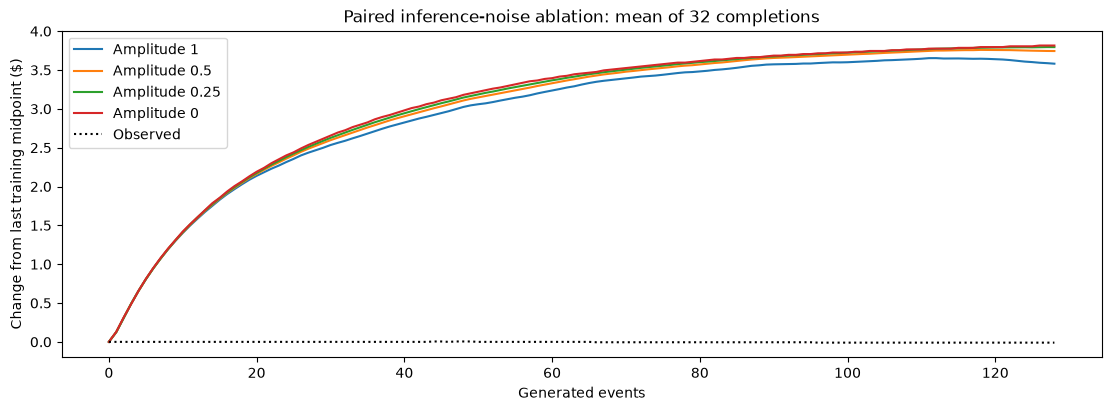

,Input variance multiplier,Mean change at 64 ($),Endpoint SD at 64 ($)
Amplitude,,,
1.00,1.0000,3.3123,0.5680
0.50,0.2500,3.3977,0.2956
0.25,0.0625,3.4305,0.1498
0.00,0.0000,3.4550,0.0000


In [2]:
model, checkpoint = load_checkpoint(project_dir / 'runs/timegan/model.pt')
length = checkpoint['training_config']['sequence_length']
context = training.features[-length:][None].repeat(32, 1, 1)
paths = noise_paths(32, 128, model, length)
anchor = midpoint(training.books)[-1]
noise_rows = []
fig, ax = plt.subplots(figsize=(11, 4), layout='constrained')
for amplitude in [1.0, 0.5, 0.25, 0.0]:
    generated = complete(model, context, paths * amplitude)
    prices = np.stack([midpoint(training.feature_sequence_to_df(window)) for window in generated])
    ax.plot(np.arange(129), np.r_[0, prices.mean(axis=0) - anchor], label=f'Amplitude {amplitude:g}')
    noise_rows.append({'Amplitude': amplitude, 'Input variance multiplier': amplitude ** 2,
                       'Mean change at 64 ($)': prices[:, 63].mean() - anchor,
                       'Endpoint SD at 64 ($)': prices[:, 63].std()})
ax.plot(np.arange(129), np.r_[0, midpoint(validation.books)[:128] - anchor],
        color='black', linestyle=':', label='Observed')
ax.set(title='Paired inference-noise ablation: mean of 32 completions',
       xlabel='Generated events', ylabel='Change from last training midpoint ($)')
ax.legend()
plt.show()
noise_summary = pd.DataFrame(noise_rows).set_index('Amplitude')
display(noise_summary.round(4))


## 2. Do training balance or a context loss fix the handoff?

The training-balance sweep fixes architecture and 1,000/1,000/5,000 stage budgets, using
one separately seeded real-data sampler. Its fresh baseline is distinct from the original
checkpoint, whose sampler shared the training RNG. Taking two generator updates doubles
the number of generator updates, not the other networks' update counts.

The context-loss sweep starts from the D-rate-1e-4 configuration. It adds decoded midpoint
supervision after a **48-event real prefix and 16 generated events**. Only the generator is
updated by that term. Squared error against one observed future may encourage smoothing.
The diagnostic starting context is 64 events for these price-level models.

Both figures use saved final diagnostics: 32 paired completions at the training boundary.
Across-context endpoint errors in the table above cover eight starting contexts. Completion
SD measures variation between generated paths, not a confidence interval or a calibration test.


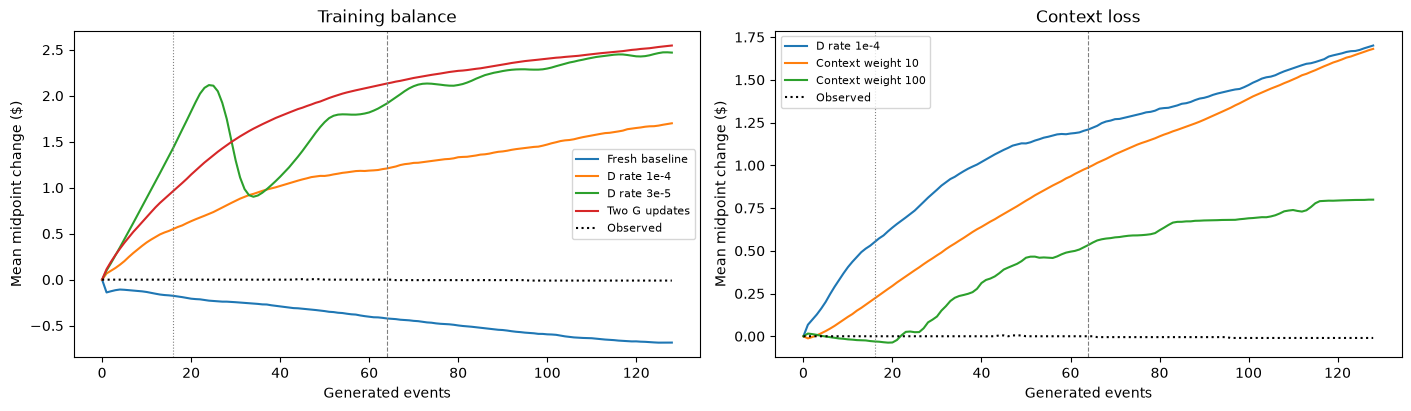

,Mean endpoint error at 16 ($),Mean endpoint error at 64 ($),Boundary endpoint SD at 64 ($)
Model,,,
D rate 1e-4,0.6123,1.5030,0.5624
Context weight 10,0.1821,0.9485,0.4241
Context weight 100,0.0193,0.5160,0.8980


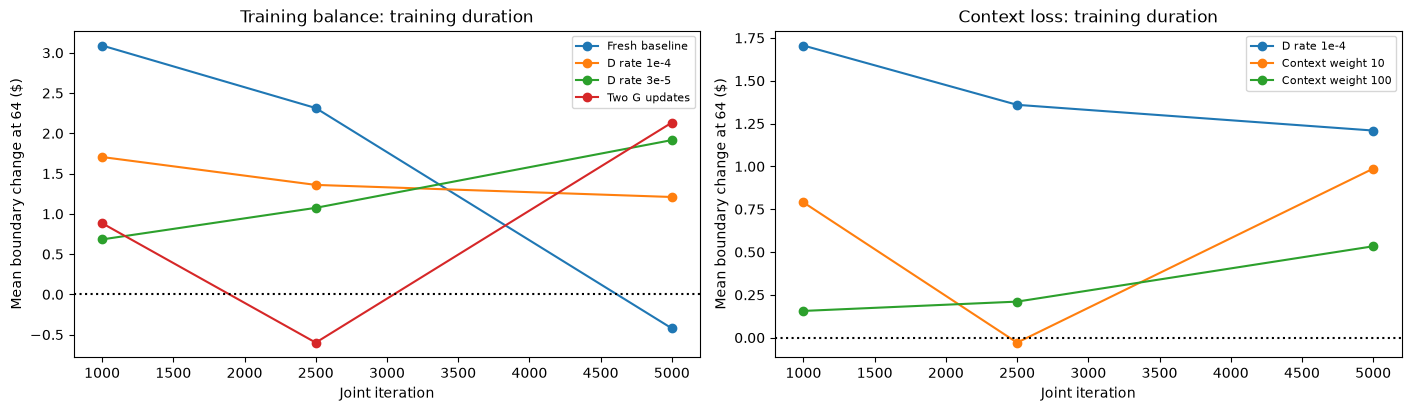

In [3]:
groups = [(['Fresh baseline', 'D rate 1e-4', 'D rate 3e-5', 'Two G updates'], 'Training balance'),
          (['D rate 1e-4', 'Context weight 10', 'Context weight 100'], 'Context loss')]
fig, axes = plt.subplots(1, 2, figsize=(14, 4), layout='constrained')
for ax, (labels, title) in zip(axes, groups):
    for label in labels:
        curves = results[label]['diagnostic']['curves']
        start = curves['starting_price_dollars']
        ax.plot(np.arange(len(curves['generated_mean']) + 1),
                np.r_[0, np.asarray(curves['generated_mean']) - start], label=label)
    ax.plot(np.arange(len(curves['observed']) + 1),
            np.r_[0, np.asarray(curves['observed']) - start], color='black', linestyle=':', label='Observed')
    ax.axvline(16, color='gray', linestyle=':', linewidth=0.8)
    ax.axvline(64, color='gray', linestyle='--', linewidth=0.8)
    ax.set(title=title, xlabel='Generated events', ylabel='Mean midpoint change ($)')
    ax.legend(fontsize=8)
plt.show()

display(summary.loc[['D rate 1e-4', 'Context weight 10', 'Context weight 100'],
                    ['context_mean_abs_16_event_error_dollars', 'context_mean_abs_64_event_error_dollars',
                     'boundary_64_event_std_dollars']].rename(columns={
                         'context_mean_abs_16_event_error_dollars': 'Mean endpoint error at 16 ($)',
                         'context_mean_abs_64_event_error_dollars': 'Mean endpoint error at 64 ($)',
                         'boundary_64_event_std_dollars': 'Boundary endpoint SD at 64 ($)'}).round(4))

# Intermediate snapshots reveal improvements that disappear with more training.
fig, axes = plt.subplots(1, 2, figsize=(14, 4), layout='constrained')
for ax, (labels, title) in zip(axes, groups):
    for label in labels:
        snapshots = pd.read_csv(results[label]['directory'] / 'snapshots.csv')
        ax.plot(snapshots['joint_step'], snapshots['boundary_64_event_change_dollars'],
                marker='o', label=label)
    ax.axhline(0, color='black', linestyle=':')
    ax.set(title=f'{title}: training duration', xlabel='Joint iteration', ylabel='Mean boundary change at 64 ($)')
    ax.legend(fontsize=8)
plt.show()


## 3. Can decoder-generated returns improve the handoff?

Resetting the Wiener clock uses the same price-level checkpoint and changes only its noise
clock. The return models change several factors together: midpoint returns, stationary
Wiener increments, return moment matching (weight 10), and cumulative-return context
supervision (weights 1 and 10). That comparison cannot isolate returns alone as the cause.

The generator predicts latent states; the **TimeGAN decoder outputs all 40 features**.
Feature zero is a standardized midpoint log return. Reverse its training normalization,
then accumulate those predicted log returns from the last observed midpoint to recover
prices. The decoder also outputs spread, gaps, and order sizes. Tick rounding occurs only
during book conversion. No external price model replaces the decoder's output, and no
fixed drift is imposed during sampling.

Return forecasts repeat the trained task in blocks of 16 events with 48 history events,
using generated history after the initial real prefix. A small learned return bias can
still accumulate. The 1,024-event comparison is an extrapolation beyond the trained
continuation horizon and must show that residual bias rather than hide it.


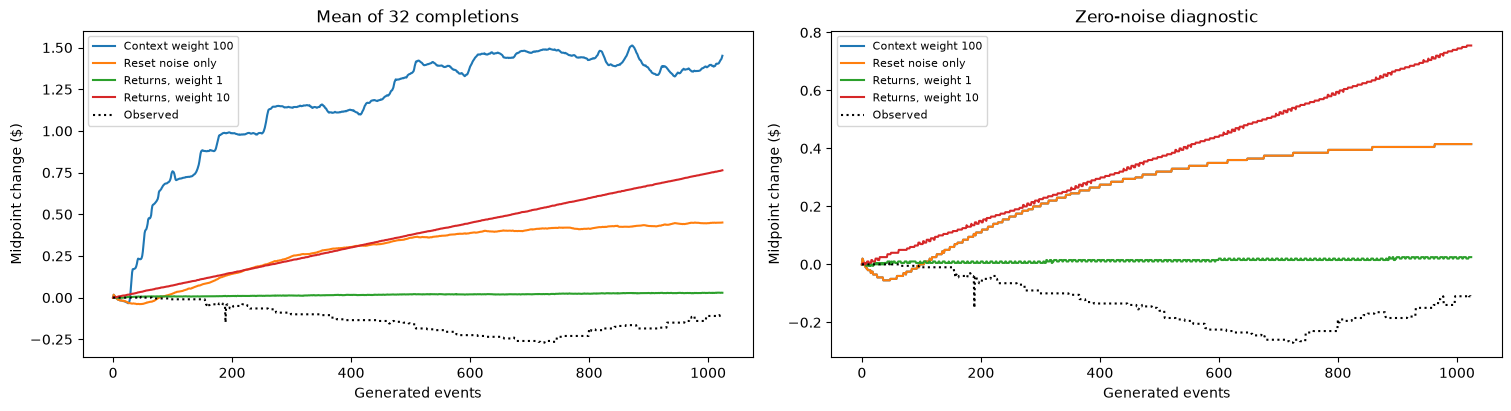

,"Mean change at 1,024 ($)","Zero-noise change at 1,024 ($)"
Model,,
Context weight 100,1.4509,0.415
Reset noise only,0.4506,0.415
"Returns, weight 1",0.0292,0.025
"Returns, weight 10",0.7639,0.755


In [4]:
labels = ['Context weight 100', 'Reset noise only', 'Returns, weight 1', 'Returns, weight 10']
# The previous-level control is the same context-weight-100 checkpoint.
long_directories = {'Context weight 100': project_dir / 'runs/return_price/previous_levels_seed_0'}
fig, axes = plt.subplots(1, 2, figsize=(15, 4), layout='constrained')
long_rows = []
for label in labels:
    directory = long_directories.get(label, results[label]['directory'])
    curves = json.loads((directory / 'long_boundary.json').read_text())
    anchor = curves['starting_price_dollars']
    for ax, field in zip(axes, ['generated_mean', 'zero_noise']):
        ax.plot(np.arange(len(curves[field]) + 1), np.r_[0, np.asarray(curves[field]) - anchor], label=label)
    long_rows.append({'Model': label, 'Mean change at 1,024 ($)': curves['generated_mean'][-1] - anchor,
                      'Zero-noise change at 1,024 ($)': curves['zero_noise'][-1] - anchor})
for ax, title in zip(axes, ['Mean of 32 completions', 'Zero-noise diagnostic']):
    ax.plot(np.arange(len(curves['observed']) + 1), np.r_[0, np.asarray(curves['observed']) - anchor],
            color='black', linestyle=':', label='Observed')
    ax.set(title=title, xlabel='Generated events', ylabel='Midpoint change ($)')
    ax.legend(fontsize=8)
plt.show()
long_summary = pd.DataFrame(long_rows).set_index('Model')
display(long_summary.round(4))


## One whole-day overview of decoder-generated returns

These saved three-path TimeGAN continuations use the context-weight-1 return checkpoint.
They start at the training boundary and use no later real observations. Every midpoint
change comes from the decoder, and prices accumulate from the last training midpoint.
Their entire range is shown. Three paths provide an illustration rather than a reliable
uncertainty estimate. Any remaining drift is a model error to assess alongside chapter 4's
book-structure and temporal checks.


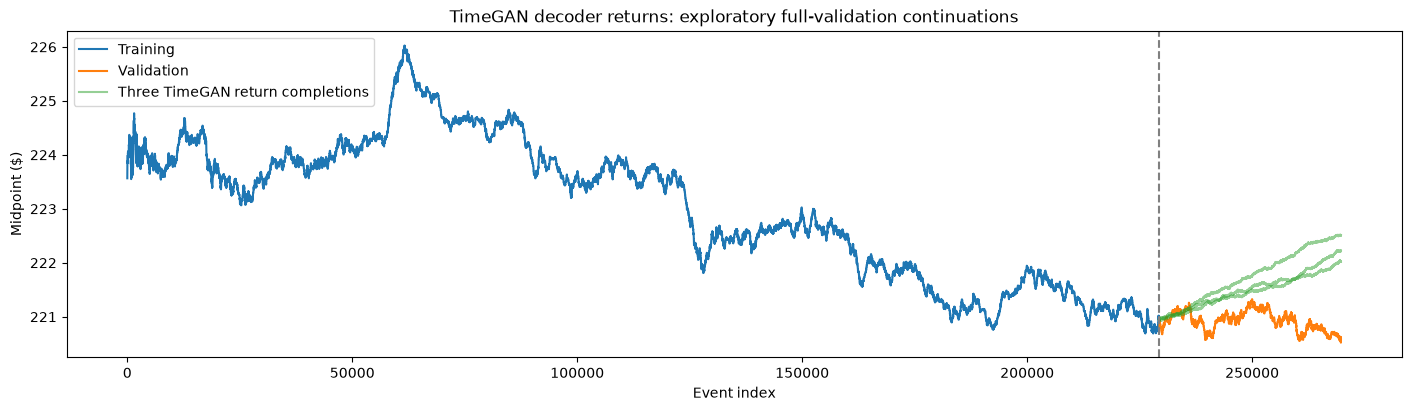

In [5]:
with np.load(results['Returns, weight 1']['directory'] / 'completion_midpoints.npz') as archive:
    prices = archive['noisy'].copy()
train_price, validation_price = midpoint(training.books), midpoint(validation.books)
boundary = len(training)
fig, ax = plt.subplots(figsize=(14, 4), layout='constrained')
ax.plot(np.arange(boundary), train_price, color='tab:blue', label='Training')
ax.plot(np.arange(boundary, boundary + len(validation)), validation_price, color='tab:orange', label='Validation')
for i, path in enumerate(prices):
    ax.plot(np.arange(boundary - 1, boundary + len(path)), np.r_[train_price[-1], path],
            color='tab:green', alpha=0.5, label='Three TimeGAN return completions' if i == 0 else None)
ax.axvline(boundary - 0.5, color='gray', linestyle='--')
ax.set(title='TimeGAN decoder returns: exploratory full-validation continuations',
       xlabel='Event index', ylabel='Midpoint ($)')
ax.ticklabel_format(axis='x', style='plain', useOffset=False)
ax.legend()
plt.show()


In [6]:
reference = summary.loc['D rate 1e-4']
context = summary.loc['Context weight 100']
return_model = summary.loc['Returns, weight 1']
zero_drift = noise_summary.loc[0.0, 'Mean change at 64 ($)']
display(Markdown(f"""
## What the experiments establish

- Turning noise off still gives **{zero_drift:+.3f} dollars** of change after 64 events
  in the original model. Noise amplitude alone cannot explain its drift.
- Training-balance changes do not reliably solve the handoff; saved intermediate
  checkpoints show that extra training can reverse an apparent improvement.
- Context weight 100 reduces mean 16-event endpoint error across eight contexts from
  **${reference['context_mean_abs_16_event_error_dollars']:.3f} to
  ${context['context_mean_abs_16_event_error_dollars']:.3f}**, but its 64-event boundary
  endpoint SD is **${context['boundary_64_event_std_dollars']:.3f}**.
- The context-weight-1 return TimeGAN's mean boundary change at 1,024 events is
  **{long_summary.loc['Returns, weight 1', 'Mean change at 1,024 ($)']:+.4f} dollars**, versus
  **{long_summary.loc['Context weight 100', 'Mean change at 1,024 ($)']:+.4f}** for the previous correction.
  These prices come from decoder-generated returns. Residual drift remains a learned-model error;
  it is not corrected by a separate price process.

One day, one training seed, and repeatedly inspected validation data support a development
case study. They do not establish generalization, calibrated uncertainty, or realistic joint
book dynamics. Keep the unsuccessful controls when interpreting the final model.
"""))



## What the experiments establish

- Turning noise off still gives **+3.455 dollars** of change after 64 events
  in the original model. Noise amplitude alone cannot explain its drift.
- Training-balance changes do not reliably solve the handoff; saved intermediate
  checkpoints show that extra training can reverse an apparent improvement.
- Context weight 100 reduces mean 16-event endpoint error across eight contexts from
  **$0.612 to
  $0.019**, but its 64-event boundary
  endpoint SD is **$0.898**.
- The context-weight-1 return TimeGAN's mean boundary change at 1,024 events is
  **+0.0292 dollars**, versus
  **+1.4509** for the previous correction.
  These prices come from decoder-generated returns. Residual drift remains a learned-model error;
  it is not corrected by a separate price process.

One day, one training seed, and repeatedly inspected validation data support a development
case study. They do not establish generalization, calibrated uncertainty, or realistic joint
book dynamics. Keep the unsuccessful controls when interpreting the final model.


## Reproducing the experiment evidence

This notebook reads saved run diagnostics and recomputes the short inference-noise
comparison. Missing 16-event metrics in older reports are recovered from their checkpoints. It neither retrains models nor rewrites existing reports. Experiment scripts,
checkpoints, losses, intermediate snapshots, and full continuations remain under `runs/`.
Those outputs are ignored by Git and must be retained separately to reproduce this local study.

Training commands and their dependencies are listed in the [notebook guide](README.md).
